In [ ]:
# ======================
# DOWNLOAD DATASET USING KAGGLEHUB
# ======================
import os
import kagglehub

path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
print("Dataset downloaded to:", path)

DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)


# ======================
# Enhanced MobileNetV2 Cattle Breed Classifier (PyTorch)
# ======================
import time, random
import numpy as np
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt   # ✅ ADDED ONLY FOR GRAPH

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Load dataset
base = datasets.ImageFolder(DATA_DIR, transform=test_transform)
class_names = base.classes
num_classes = len(class_names)
print("Class Names:", class_names)


# ======================
# STRATIFIED SPLIT
# ======================
def stratified_split(dataset, train_ratio=0.8, val_ratio=0.1):
    rng = np.random.default_rng(42)
    idxs = defaultdict(list)
    for i, (_, lb) in enumerate(dataset.samples):
        idxs[lb].append(i)

    train, val, test = [], [], []

    for lb, arr in idxs.items():
        arr = np.array(arr)
        rng.shuffle(arr)
        n = len(arr)
        t = int(train_ratio*n)
        v = int(val_ratio*n)
        train.extend(arr[:t])
        val.extend(arr[t:t+v])
        test.extend(arr[t+v:])

    return train, val, test

train_idx, val_idx, test_idx = stratified_split(base)


# ======================
# Subset Loader
# ======================
class SubsetWithTransform(Dataset):
    def __init__(self, base, idxs, tfm):
        self.base = base
        self.idxs = idxs
        self.samples = base.samples
        self.transform = tfm

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        real = self.idxs[i]
        path, label = self.samples[real]
        img = self.base.loader(path)
        return self.transform(img), label


train_ds = SubsetWithTransform(base, train_idx, train_transform)
val_ds   = SubsetWithTransform(base, val_idx, test_transform)
test_ds  = SubsetWithTransform(base, test_idx, test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)


# ======================
# MobileNetV2 MODEL
# ======================
class MobileNetEnhanced(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        m = models.mobilenet_v2(weights=weights)

        for p in m.features[:-4].parameters():
            p.requires_grad = False

        self.features = m.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        in_dim = m.classifier[1].in_features

        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).reshape(x.size(0), -1)
        return self.classifier(x)


model = MobileNetEnhanced(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


# ======================
# GRAPH STORAGE (✅ ONLY STORAGE)
# ======================
train_acc_list = []
val_acc_list = []


# ======================
# TRAIN LOOP (UNCHANGED LOGIC)
# ======================
def train(model, epochs=20):
    for ep in range(epochs):
        model.train()
        total, correct = 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            correct += (out.argmax(1)==labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_acc_list.append(train_acc)   # ✅ STORE ONLY

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(1)
                v_correct += (preds == labels).sum().item()
                v_total += labels.size(0)

        val_acc = 100 * v_correct / v_total
        val_acc_list.append(val_acc)       # ✅ STORE ONLY

        scheduler.step()

        print(f"Epoch {ep+1}/{epochs} | Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")

    return model


model = train(model, 25)


# ======================
# ACCURACY GRAPH (SAFE)
# ======================
epochs_range = range(1, len(train_acc_list) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_acc_list, marker='o', label="Training Accuracy")
plt.plot(epochs_range, val_acc_list, marker='s', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ======================
# TEST RESULTS
# ======================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nTEST ACCURACY & REPORT")
print(classification_report(all_labels, all_preds, target_names=class_names))


In [ ]:
# ============================
# IMAGE PREDICTION (UPLOAD FILE)
# ============================

from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt   # <-- ADD THIS

uploaded = files.upload()  # Choose an image

for filename in uploaded.keys():
    img_path = filename
    print("Image:", img_path)

    # Load the image
    img = Image.open(img_path).convert("RGB")

    # Apply same preprocess as test dataset
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225],
        ),
    ])

    x = tfm(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        pred_idx = prob.argmax().item()

    print("\nPredicted Breed:", class_names[pred_idx])
    print("Confidence:", float(prob[pred_idx]))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[pred_idx]} ({prob[pred_idx]*100:.2f}%)")
    plt.show()


TypeError: 'NoneType' object is not subscriptable

Saving bs.jpg to bs.jpg
Image: bs.jpg

Predicted Breed: Brown Swiss cattle
Confidence: 0.9334316849708557


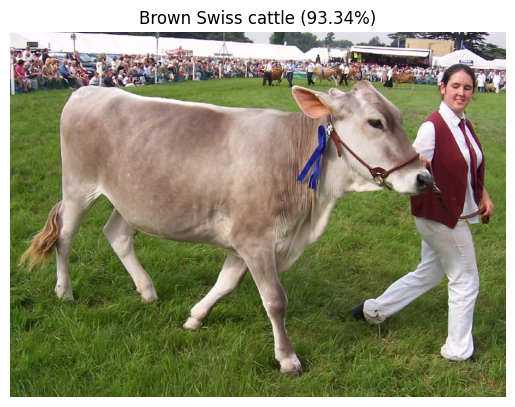

In [ ]:
# ============================
# IMAGE PREDICTION (UPLOAD FILE)
# ============================

from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt   # <-- ADD THIS

uploaded = files.upload()  # Choose an image

for filename in uploaded.keys():
    img_path = filename
    print("Image:", img_path)

    # Load the image
    img = Image.open(img_path).convert("RGB")

    # Apply same preprocess as test dataset
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225],
        ),
    ])

    x = tfm(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        pred_idx = prob.argmax().item()

    print("\nPredicted Breed:", class_names[pred_idx])
    print("Confidence:", float(prob[pred_idx]))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[pred_idx]} ({prob[pred_idx]*100:.2f}%)")
    plt.show()
